# S09: Taylor Polynomial Applications


# Limits

In [1]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
from sympy import Function, diff, Symbol, latex
from sympy.plotting import plot
from IPython.display import Math, display

Most of what follows happens automatically (and invisibly) when we call the sympy `limit` function. But instead of that *black box* approach we can look inside the computation to gain a deeper understanding of what is going on inside that box.

$(a) \quad \displaystyle\lim_{x\to 0}\dfrac{e^{2x} - \cos{2x}}{e^{5x} - \cos{3x}}\qquad$  $(b) \quad \displaystyle\lim_{x\to 0}\dfrac{2\cos{x} + x^2 - 2}{x^4}$


$(c) \quad \displaystyle\lim_{x\to 0}\dfrac{1 - \sqrt{1 + x^4}\cos(2x^2)}{x\, (\tan x -\sinh x)}\qquad$  $(d)\quad \displaystyle{\lim_{ x\to 2}}\dfrac{x^3 - 3x^2 + 4}{x^3 - x^2 -8x + 12}$

In [2]:
x = sy.Symbol('x')
f1 = sy.exp(2 * x) - sy.cos(2 * x)
g1 = sy.exp(5 * x) - sy.cos(3 * x)
display(Math(f"f(x) = {latex(f1/g1)}"))


<IPython.core.display.Math object>

Now we can get the Taylor polynomials (and therefore the principal part) for the numerator and denominator. If you get 0 as the answer for any of the polynomials, that means you have to use a higher order.

In [3]:
n = 5

In [4]:
# Get the taylor polynomial of f1
Pnf1 = sy.series(f1, x, 0, n+1).removeO()
display(Math(f"P_{ {n} }f_1(x) = {latex(Pnf1)}"))
# Extract the lowest degree term in the taylor polynomial of f1
PPf1 = Pnf1.as_ordered_terms()[-1]
display(Math(f"PP(f_1(x)) = {latex(PPf1)}"))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

Repeat the same for the remaining factors in the limit.

In [5]:
# Get the taylor polynomial of f1
Png1 = sy.series(g1, x, 0, n+1).removeO()
display(Math(f"P_{ {n} }g_1(x) = {latex(Png1)}"))
# Extract the lowest degree term in the taylor polynomial of g1
PPg1 = Pnf1.as_ordered_terms()[-1]
display(Math(f"PP(g_1(x)) = {latex(PPg1)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

A direct computation of the limit is:

In [6]:
sy.limit(f1 / g1, x, 0)

2/5

Which gives the same result as using the principal parts.

In [7]:
sy.limit(PPf1 / PPg1, x, 0)

1

# Function approximation and Lagrange's formula

In [10]:
f = sy.sqrt(1 + x)
display(Math(f"f(x) = {latex(f)}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [74]:
n = 5
x0 = 0
f_series = sy.series(f, x, 0, n + 1).removeO()
display(Math(f"f(x) = {latex(f_series)}"))


<IPython.core.display.Math object>

In [75]:
p = 0.02
# a symbolic version
p = sy.Rational(2, 100)
f_series.subs(x, p), f_series.subs(x, p).evalf()



(80796039507/80000000000, 1.00995049383750)

In [76]:
f.subs(x, p), f.subs(x, p).evalf()

(sqrt(102)/10, 1.00995049383621)

In [77]:
df_R = sy.diff(f, x, n + 1)
display(Math(f"f^{{({n + 1})}}(x) = {latex(df_R)}"))



<IPython.core.display.Math object>

Now we plot the absolute value of this derivative in the interval [x0, p]. Be careful: the horizontal axis in the plot is **not** the $X$ axis.

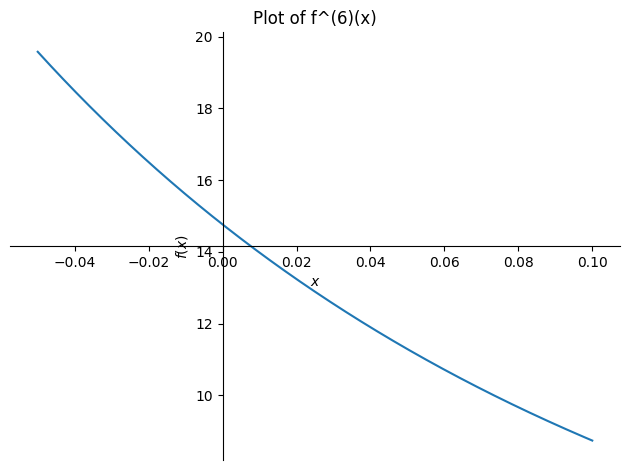

In [78]:
p_df_R = sy.plotting.plot(sy.Abs(df_R), (x, -0.05, 0.1), show=False, title=f'Plot of f^({n+1})(x)')
p_df_R.show()

The plot confirms that the absolute value of the derivative in Lagrange's formula is decreasing in the interval between $x_0 = 0$ and $p = 0.02$. Therefore, even if we don't know $c$ we can be sure that:
$$f^{(3)}(p) < f^{(3)}(c) < f^{(3)}(0)$$
To get an upper bound for the error we pick the biggest of these values, namely:

In [79]:
df_R_bound = df_R.subs(x, x0).evalf()
display(Math(f"f^{{(3)}}(0) = {latex(df_R_bound)}"))

<IPython.core.display.Math object>

And so for the error we get:

In [80]:
Error_Pf = sy.Abs(df_R_bound * (x0 - p)**n / sy.factorial(n + 1))
display(Math(f"E_n = {latex(Error_Pf)}"))

<IPython.core.display.Math object>

And this is in fact an upper bound because the (more precise) value computed by sympy verifies:

In [81]:
sy.Abs(f_series.subs(x, p).evalf() - f.subs(x, p).evalf())

1.29207755605876e-12